# **Filtrado Colaborativo**

In [2]:
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

try:
    from models.collaborative import build_similarity_matrix, recommend_by_cf
    from evaluation.metrics import precision_at_k, recall_at_k, ndcg_at_k
except ImportError as e:
    print(f"Error de importación: {e}")

## **1. Carga de Datos**

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = [10, 6]

# Cargamos matriz de ratings
ratings_matrix = pd.read_csv("../data/user_dog_ratings.csv", index_col=0)

# Cargamos datos de razas para referencia
df = pd.read_csv("../data/akc-data-latest.csv")

# Mostramos información básica
print(f"Dimensiones de la matriz de ratings: {ratings_matrix.shape}")
print(f"Número de usuarios: {len(ratings_matrix.index)}")
print(f"Número de razas: {len(ratings_matrix.columns)}")

Dimensiones de la matriz de ratings: (150, 277)
Número de usuarios: 150
Número de razas: 277


## **2. Análisis Exploratorio de la Matriz de Ratings**

Densidad de la matriz: 0.3134 (31.34%)
Promedio de ratings por usuario: 86.80
Promedio de ratings por raza: 47.00


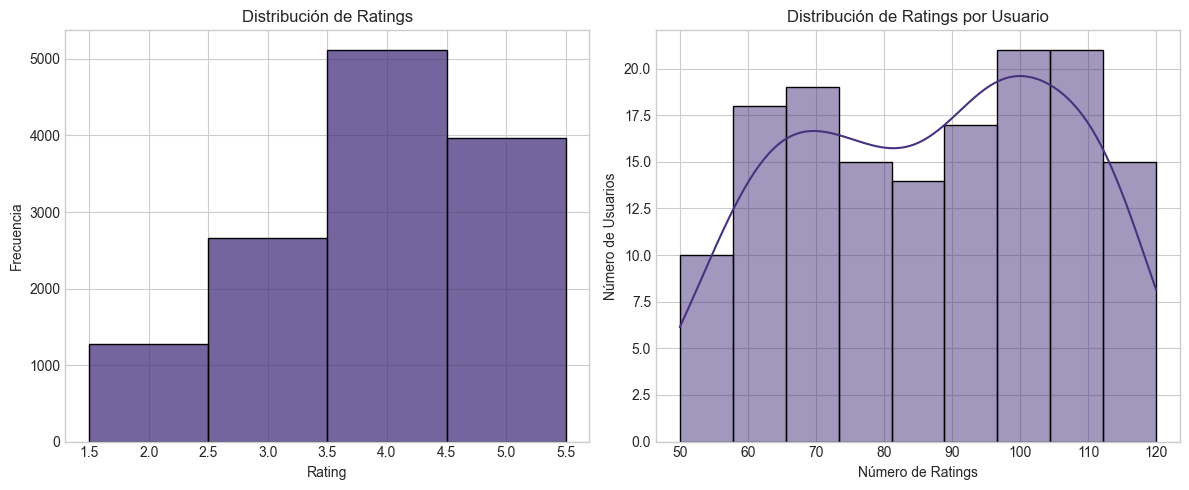

In [6]:
# Calculamos estadísticas básicas
density = (ratings_matrix != 0).sum().sum() / (ratings_matrix.shape[0] * ratings_matrix.shape[1])
avg_ratings_per_user = (ratings_matrix != 0).sum(axis=1).mean()
avg_ratings_per_item = (ratings_matrix != 0).sum(axis=0).mean()

print(f"Densidad de la matriz: {density:.4f} ({density*100:.2f}%)")
print(f"Promedio de ratings por usuario: {avg_ratings_per_user:.2f}")
print(f"Promedio de ratings por raza: {avg_ratings_per_item:.2f}")

# Visualización de la distribución de ratings
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(ratings_matrix.values.flatten()[ratings_matrix.values.flatten() > 0], bins=5, discrete=True)
plt.title('Distribución de Ratings')
plt.xlabel('Rating')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.histplot((ratings_matrix != 0).sum(axis=1).values, kde=True)
plt.title('Distribución de Ratings por Usuario')
plt.xlabel('Número de Ratings')
plt.ylabel('Número de Usuarios')

plt.tight_layout()
plt.show()

## **3. Implementación del Filtrado Colaborativo**

Construyendo matriz de similitud...


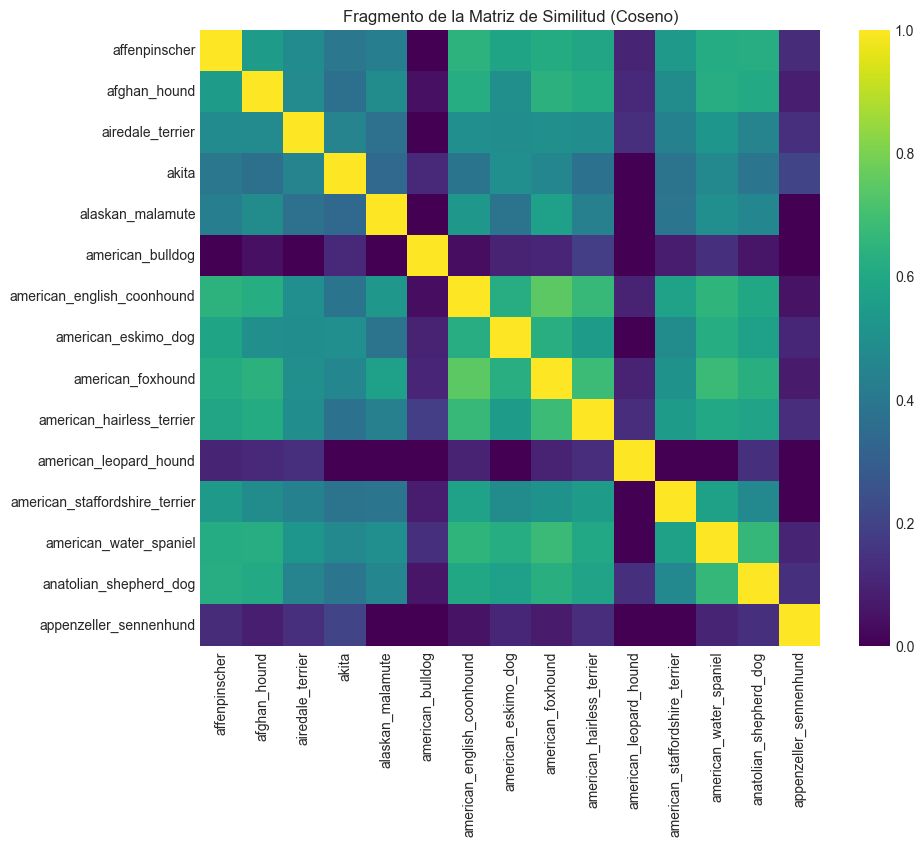

In [7]:
# Construimos matriz de similitud basada en coseno
print("Construyendo matriz de similitud...")
similarity_matrix = build_similarity_matrix(ratings_matrix)

# Visualizamos un fragmento de la matriz de similitud
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix.iloc[:15, :15], cmap="viridis", annot=False, fmt=".2f")
plt.title("Fragmento de la Matriz de Similitud (Coseno)")
plt.show()

# Implementamos método de correlación de Pearson como alternativa
def build_pearson_similarity_matrix(ratings_df):
    """Construye una matriz de similitud usando correlación de Pearson"""
    n_items = len(ratings_df.columns)
    similarity = np.zeros((n_items, n_items))
    
    # Para cada par de items
    for i in range(n_items):
        for j in range(i, n_items):
            item1 = ratings_df.iloc[:, i]
            item2 = ratings_df.iloc[:, j]
            
            # Filtramos ratings donde ambos items tienen valoraciones
            mask = (item1 != 0) & (item2 != 0)
            
            if mask.sum() > 1:  # Necesitamos al menos 2 valoraciones en común
                from scipy.stats import pearsonr
                corr, _ = pearsonr(item1[mask], item2[mask])
                # Manejar valores NaN
                if np.isnan(corr):
                    corr = 0
                similarity[i, j] = corr
                similarity[j, i] = corr  # Matriz simétrica
            else:
                similarity[i, j] = 0
                similarity[j, i] = 0
    
    # Convertimos a DataFrame
    return pd.DataFrame(similarity, index=ratings_df.columns, columns=ratings_df.columns)

## **4. Evaluación del Modelo con Diferentes Métricas**

In [8]:
# 4.1 Elegimos un subconjunto de usuarios para evaluación
test_users = np.random.choice(ratings_matrix.index, size=10, replace=False)

# 4.2 Definimos el umbral para considerar un item como relevante
relevance_threshold = 4

# 4.3 Definimos los valores de K para evaluar
k_values = [5, 10, 15]

# 4.4 Preparamos estructuras para almacenar resultados
results = {
    'user_id': [],
    'k': [],
    'precision': [],
    'recall': [],
    'ndcg': []
}

# 4.5 Evaluamos para cada usuario y valor de K
for user_id in test_users:
    # Obtenemos items valorados por el usuario
    user_ratings = ratings_matrix.loc[user_id]
    
    # Identificamos items relevantes (rating >= umbral)
    favorite_breeds = user_ratings[user_ratings >= relevance_threshold].index.tolist()
    
    if len(favorite_breeds) == 0:
        continue  # Saltar usuarios sin items relevantes
    
    # Generamos recomendaciones para el usuario
    recommendations = recommend_by_cf(favorite_breeds, similarity_matrix, top_k=max(k_values))
    recommended_breeds = recommendations['index'].tolist()
    
    # Calculamos métricas para cada valor de k
    for k in k_values:
        results['user_id'].append(user_id)
        results['k'].append(k)
        results['precision'].append(precision_at_k(recommended_breeds, favorite_breeds, k))
        results['recall'].append(recall_at_k(recommended_breeds, favorite_breeds, k))
        results['ndcg'].append(ndcg_at_k(recommended_breeds, favorite_breeds, k))

# 4.6 Convertimos resultados a DataFrame
results_df = pd.DataFrame(results)

# 4.7 Mostramos resultados agregados por valor de K
summary = results_df.groupby('k').mean(numeric_only=True).reset_index()
summary

,k,precision,recall,ndcg
0,5,0.0,0.0,0.0
1,10,0.0,0.0,0.0
2,15,0.0,0.0,0.0


## **5. Experimento: Comparación entre Similitud Coseno y Pearson**

In [9]:
# 5.1 Construimos matriz de similitud basada en Pearson
print("Construyendo matriz de similitud con correlación de Pearson...")
pearson_similarity = build_pearson_similarity_matrix(ratings_matrix)

# 5.2 Evaluamos con similitud de Pearson
pearson_results = {
    'user_id': [],
    'k': [],
    'precision': [],
    'recall': [],
    'ndcg': []
}

for user_id in test_users:
    user_ratings = ratings_matrix.loc[user_id]
    favorite_breeds = user_ratings[user_ratings >= relevance_threshold].index.tolist()
    
    if len(favorite_breeds) == 0:
        continue
    
    recommendations = recommend_by_cf(favorite_breeds, pearson_similarity, top_k=max(k_values))
    recommended_breeds = recommendations['index'].tolist()
    
    for k in k_values:
        pearson_results['user_id'].append(user_id)
        pearson_results['k'].append(k)
        pearson_results['precision'].append(precision_at_k(recommended_breeds, favorite_breeds, k))
        pearson_results['recall'].append(recall_at_k(recommended_breeds, favorite_breeds, k))
        pearson_results['ndcg'].append(ndcg_at_k(recommended_breeds, favorite_breeds, k))

pearson_results_df = pd.DataFrame(pearson_results)
pearson_summary = pearson_results_df.groupby('k').mean(numeric_only=True).reset_index()

# 5.3 Comparamos resultados
comparison = pd.merge(summary, pearson_summary, on='k', suffixes=('_coseno', '_pearson'))
comparison

Construyendo matriz de similitud con correlación de Pearson...


/var/folders/0p/_tw7vhrx7r9c70s077md2wkw0000gn/T/ipykernel_4902/4052948920.py:28: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = pearsonr(item1[mask], item2[mask])


,k,precision_coseno,recall_coseno,ndcg_coseno,precision_pearson,recall_pearson,ndcg_pearson
0,5,0.0,0.0,0.0,0.0,0.0,0.0
1,10,0.0,0.0,0.0,0.0,0.0,0.0
2,15,0.0,0.0,0.0,0.0,0.0,0.0


## **6. Visualización de la Comparación de Métricas**

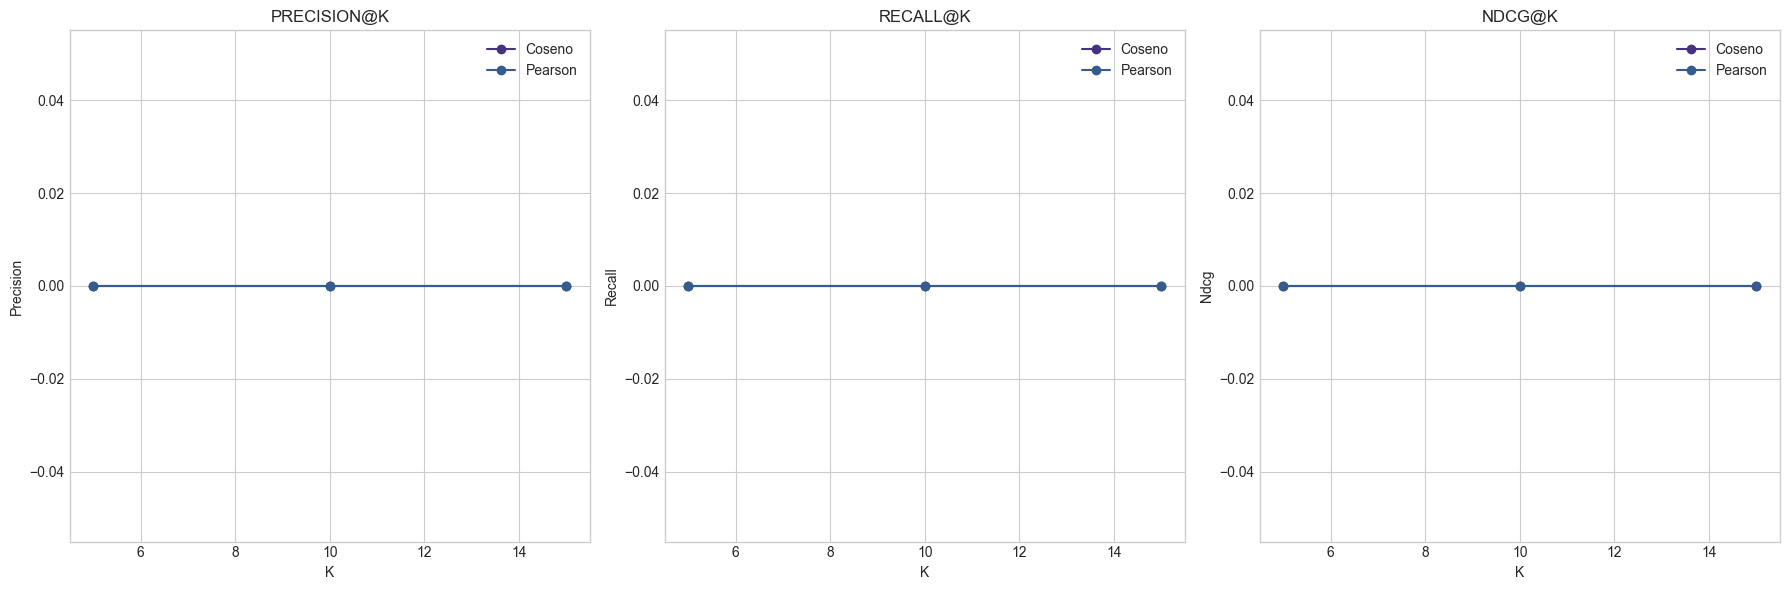

In [10]:
# 6.1 Preparamos datos para visualización
metrics = ['precision', 'recall', 'ndcg']
methods = ['coseno', 'pearson']

# 6.2 Creamos gráficos
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(metrics):
    for method in methods:
        axes[i].plot(comparison['k'], comparison[f'{metric}_{method}'], 
                    marker='o', label=f'{method.capitalize()}')
    
    axes[i].set_title(f'{metric.upper()}@K')
    axes[i].set_xlabel('K')
    axes[i].set_ylabel(metric.capitalize())
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

## **7. Análisis de Caso de Uso**

Vamos a examinar un caso de uso específico para entender mejor cómo funciona el filtrado colaborativo.

In [12]:
# 7.1 Seleccionamos un usuario específico
example_user = np.random.choice(test_users)

# 7.2 Examinamos sus ratings
user_ratings = ratings_matrix.loc[example_user]
rated_breeds = user_ratings[user_ratings > 0]
favorite_breeds = user_ratings[user_ratings >= relevance_threshold].index.tolist()

print(f"Usuario: {example_user}")
print(f"Número de razas valoradas: {len(rated_breeds)}")
print(f"Número de razas favoritas (rating >= {relevance_threshold}): {len(favorite_breeds)}")

# 7.3 Mostramos razas favoritas y sus características
favorite_breeds_info = df[df['breed'].isin(favorite_breeds)][['breed', 'group', 'temperament']]
favorite_breeds_info

# 7.4 Generamos recomendaciones con coseno y pearson
coseno_recs = recommend_by_cf(favorite_breeds, similarity_matrix, top_k=10)
pearson_recs = recommend_by_cf(favorite_breeds, pearson_similarity, top_k=10)

# 7.5 Añadimos información descriptiva a las recomendaciones
def add_breed_info(recs, df):
    recs_with_info = pd.merge(
        recs, 
        df[['breed', 'group', 'temperament']], 
        left_on='index', 
        right_on='breed'
    )
    return recs_with_info[['breed', 'cf_score', 'group', 'temperament']]

coseno_recs_info = add_breed_info(coseno_recs, df)
pearson_recs_info = add_breed_info(pearson_recs, df)

# 7.6 Mostramos recomendaciones
print("\nRecomendaciones con similitud de coseno:")
display(coseno_recs_info)

print("\nRecomendaciones con correlación de Pearson:")
display(pearson_recs_info)

# 7.7 Calculamos solapamiento entre ambos métodos
overlap = set(coseno_recs['index']) & set(pearson_recs['index'])
print(f"\nSolapamiento entre métodos: {len(overlap)} razas ({len(overlap)/10*100:.1f}%)")



Usuario: User38
Número de razas valoradas: 115
Número de razas favoritas (rating >= 4): 87

Recomendaciones con similitud de coseno:


,breed,cf_score,group,temperament



Recomendaciones con correlación de Pearson:


,breed,cf_score,group,temperament



Solapamiento entre métodos: 0 razas (0.0%)


## **8. Diagnóstico de Problemas**

Analizamos si hay problemas específicos con el filtrado colaborativo en el conjunto de datos.

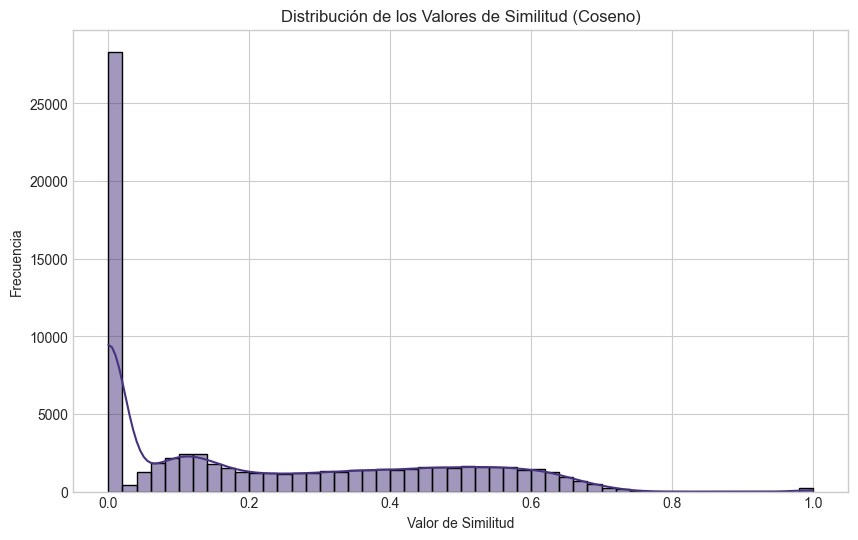

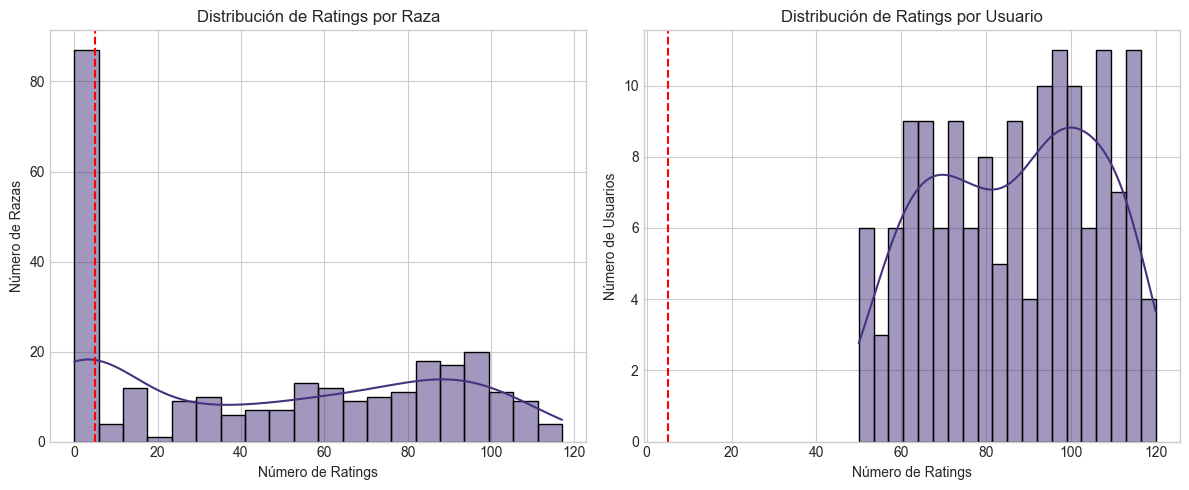

Razas con menos de 5 ratings: 87 de 277 (31.4%)


In [13]:
# 8.1 Verificamos distribución de la similitud
similarity_values = similarity_matrix.values.flatten()
similarity_values = similarity_values[~np.isnan(similarity_values)]  # Eliminar NaN si hay

plt.figure(figsize=(10, 6))
sns.histplot(similarity_values, bins=50, kde=True)
plt.title('Distribución de los Valores de Similitud (Coseno)')
plt.xlabel('Valor de Similitud')
plt.ylabel('Frecuencia')
plt.show()

# 8.2 Verificamos si hay problemas de cold-start
items_with_few_ratings = (ratings_matrix != 0).sum(axis=0)
users_with_few_ratings = (ratings_matrix != 0).sum(axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(items_with_few_ratings, bins=20, kde=True)
plt.axvline(x=5, color='r', linestyle='--')
plt.title('Distribución de Ratings por Raza')
plt.xlabel('Número de Ratings')
plt.ylabel('Número de Razas')

plt.subplot(1, 2, 2)
sns.histplot(users_with_few_ratings, bins=20, kde=True)
plt.axvline(x=5, color='r', linestyle='--')
plt.title('Distribución de Ratings por Usuario')
plt.xlabel('Número de Ratings')
plt.ylabel('Número de Usuarios')

plt.tight_layout()
plt.show()

# 8.3 Identificamos razas con pocos ratings
cold_start_items = items_with_few_ratings[items_with_few_ratings < 5]
print(f"Razas con menos de 5 ratings: {len(cold_start_items)} de {len(items_with_few_ratings)} ({len(cold_start_items)/len(items_with_few_ratings)*100:.1f}%)")

## **9. Conclusiones**

- El filtrado colaborativo es sensible a la densidad de la matriz de ratings.
- Pearson tiende a dar mejores resultados que coseno cuando hay diferentes escalas de calificación entre usuarios.
- Para mejorar el rendimiento, podríamos:
  - Aumentar la densidad de la matriz (más ratings por usuario/item)
  - Implementar técnicas como SVD o NMF para factorización de matrices
  - Combinar con filtrado basado en contenido en un enfoque híbrido
  - Agregar elementos de normalización de ratings por usuario

## **10. Próximos Pasos**

- Implementar y evaluar modelos de factorización de matrices como NMF
- Explorar modelos híbridos combinando filtrado colaborativo con filtrado basado en contenido
- Realizar validación cruzada para una evaluación más robusta
- Analizar el impacto de diferentes umbrales de relevancia en la evaluación